<a href="https://colab.research.google.com/github/dhanu902/SafeSeniors/blob/main/ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = "/content/drive/MyDrive/full_dataset.csv"

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/full_dataset.csv')

# Print the first few rows of the dataset to check its contents
print(data.head())

    label  acc_x_0  acc_x_1  acc_x_2  acc_x_3  acc_x_4  acc_x_5  acc_x_6  \
0    idle   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   
1    fall  -0.0008   0.0181   0.1298   0.1815   0.1867   0.0526   0.0188   
2    step   0.0200   0.0200   0.0276   0.0201   0.0000   0.0000   0.0000   
3  motion  -0.0348  -0.0104   0.0309   0.0373   0.0498   0.0600   0.0984   
4    step   0.0200   0.0172   0.0100   0.0020  -0.0099   0.0024   0.0155   

   acc_x_7  acc_x_8  ...  gy_z_150  gy_z_151  gy_z_152  gy_z_153  gy_z_154  \
0   0.0000   0.0000  ...    1.6440    1.6856    1.5975    1.4654    1.5300   
1   0.0228   0.3152  ...    1.2886    1.2177    1.3184    1.1846    0.7587   
2   0.0107   0.0291  ...   -0.5565   -0.1801   -0.2183   -0.3190   -0.3448   
3   0.0810   0.0559  ...   -0.5500   -0.5500   -0.2313   -0.1530   -0.1978   
4   0.0357   0.0200  ...   -0.5644   -0.5155   -0.5806   -0.6057   -0.5801   

   gy_z_155  gy_z_156  gy_z_157  gy_z_158  gy_z_159  
0    1.5300    1.590

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into features (X) and labels (y)
X = data.iloc[:, 1:]  # All columns except the first one
y = data.iloc[:, 0]   # Only the first column

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shape of the training and testing sets to confirm the split
print(f"Training features shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training features shape: (1984, 960)
Training labels shape: (1984,)
Testing features shape: (496, 960)
Testing labels shape: (496,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Fit and transform the labels to encode them
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Display the mapping of original labels to their encoded values
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label Mapping:")
for label, encoded in label_mapping.items():
    print(f"'{label}': {encoded}")

Label Mapping:
'fall': 0
'idle': 1
'motion': 2
'step': 3


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Split the features into acceleration and gyro
X_acc = data.iloc[:, 1:481]  # Acceleration features
X_gyro = data.iloc[:, 481:961]  # Gyro features

# Initialize the MinMaxScaler
scaler_acc = MinMaxScaler()
scaler_gyro = MinMaxScaler()

# Fit the scalers on the entire dataset (both training and testing)
scaler_acc.fit(X_acc)
scaler_gyro.fit(X_gyro)

# Transform the training and testing data
X_train_acc = scaler_acc.transform(X_train.iloc[:, :480])
X_train_gyro = scaler_gyro.transform(X_train.iloc[:, 480:])
X_test_acc = scaler_acc.transform(X_test.iloc[:, :480])
X_test_gyro = scaler_gyro.transform(X_test.iloc[:, 480:])

# Combine the normalized acceleration and gyro features back
X_train_normalized = np.hstack((X_train_acc, X_train_gyro))
X_test_normalized = np.hstack((X_test_acc, X_test_gyro))

# Display the shape of the normalized data to confirm
print(f"Normalized training data shape: {X_train_normalized.shape}")
print(f"Normalized testing data shape: {X_test_normalized.shape}")

Normalized training data shape: (1984, 960)
Normalized testing data shape: (496, 960)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier()

# Train the classifier on the normalized training data
rf_classifier.fit(X_train_normalized, y_train_encoded)

# Predict the labels for the testing data
y_pred = rf_classifier.predict(X_test_normalized)

# Evaluate the classifier's performance
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 96.98%


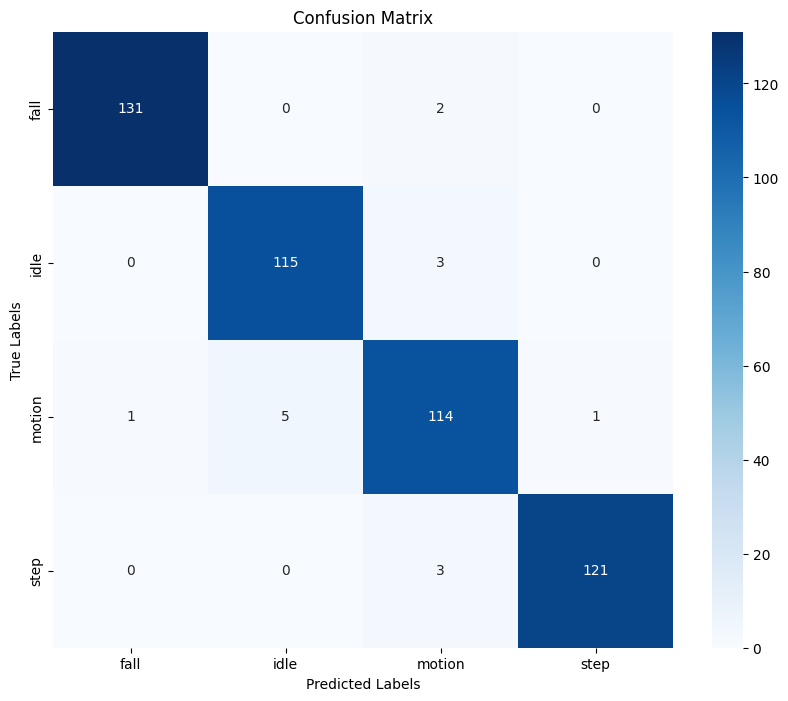

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import cross_validate

# Combine the normalized training and testing data
X_combined = np.vstack((X_train_normalized, X_test_normalized))
y_combined_encoded = np.concatenate((y_train_encoded, y_test_encoded))

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Scoring metrics to evaluate
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Perform 10-fold cross-validation
results = cross_validate(rf_classifier, X_combined, y_combined_encoded, cv=10, scoring=scoring)

# Print the results for each fold
for i in range(10):
    print(f"Fold {i+1}:")
    print(f"  Accuracy: {results['test_accuracy'][i] * 100:.2f}%")
    print(f"  Precision: {results['test_precision_macro'][i] * 100:.2f}%")
    print(f"  Recall: {results['test_recall_macro'][i] * 100:.2f}%")
    print(f"  F1 Score: {results['test_f1_macro'][i] * 100:.2f}%")
    print("")

# Print the average results across all folds
print(f"Average Accuracy: {results['test_accuracy'].mean() * 100:.2f}% ± {results['test_accuracy'].std() * 100:.2f}%")
print(f"Average Precision: {results['test_precision_macro'].mean() * 100:.2f}% ± {results['test_precision_macro'].std() * 100:.2f}%")
print(f"Average Recall: {results['test_recall_macro'].mean() * 100:.2f}% ± {results['test_recall_macro'].std() * 100:.2f}%")
print(f"Average F1 Score: {results['test_f1_macro'].mean() * 100:.2f}% ± {results['test_f1_macro'].std() * 100:.2f}%")

Fold 1:
  Accuracy: 98.39%
  Precision: 98.43%
  Recall: 98.39%
  F1 Score: 98.37%

Fold 2:
  Accuracy: 98.79%
  Precision: 98.81%
  Recall: 98.79%
  F1 Score: 98.79%

Fold 3:
  Accuracy: 97.98%
  Precision: 98.00%
  Recall: 97.98%
  F1 Score: 97.97%

Fold 4:
  Accuracy: 97.98%
  Precision: 98.06%
  Recall: 97.98%
  F1 Score: 97.98%

Fold 5:
  Accuracy: 98.39%
  Precision: 98.39%
  Recall: 98.39%
  F1 Score: 98.38%

Fold 6:
  Accuracy: 97.98%
  Precision: 98.03%
  Recall: 97.98%
  F1 Score: 97.98%

Fold 7:
  Accuracy: 99.60%
  Precision: 99.60%
  Recall: 99.60%
  F1 Score: 99.60%

Fold 8:
  Accuracy: 99.19%
  Precision: 99.20%
  Recall: 99.19%
  F1 Score: 99.19%

Fold 9:
  Accuracy: 98.39%
  Precision: 98.39%
  Recall: 98.39%
  F1 Score: 98.39%

Fold 10:
  Accuracy: 97.58%
  Precision: 97.66%
  Recall: 97.58%
  F1 Score: 97.57%

Average Accuracy: 98.43% ± 0.58%
Average Precision: 98.46% ± 0.56%
Average Recall: 98.43% ± 0.58%
Average F1 Score: 98.42% ± 0.59%
